# Day 1 — PyTorch Basics & Your First Neural Network

**Phase 2 · Deep Learning Essentials · Day 1 / 3**

In this project you will go from raw tensors to a fully working classifier on **MNIST**.

### What you will build today
A small **Multi-Layer Perceptron (MLP)** that learns to recognise handwritten digits (0–9).

### Learning goals
1. Understand **tensors** and why deep learning frameworks need them.
2. See **autograd** in action — automatic differentiation that powers backpropagation.
3. Build a model with **`nn.Module`**, train it with an **optimizer** and a **loss function**.
4. Write a complete **training loop** that you can reuse for any future project.
5. Evaluate the model and visualise its predictions.

> Estimated time: **60–90 minutes** (theory ~25 min, coding ~45 min, exploration ~20 min).


## 1. Setup — imports and device

We import:
- **PyTorch** (`torch`, `torch.nn`, `torch.optim`) for tensors, layers and optimisers
- **torchvision** for the MNIST dataset and image transforms
- **matplotlib** for plotting

We also detect the device automatically — if a GPU is available it is much faster.


In [1]:
# Core libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

# Reproducibility — same random numbers every run
torch.manual_seed(42)
np.random.seed(42)

# Pick GPU if available, else CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())
print("Using device    :", device)

PyTorch version : 2.9.1+cu128
CUDA available  : True
Using device    : cuda


## 2. Tensors — the building blocks

A **tensor** is a multi-dimensional array (like NumPy's `ndarray`) with two superpowers:

1. It can live on a **GPU** for fast parallel maths.
2. It can **track gradients** automatically — the engine behind training.

You can think of:
- A **scalar** as a 0-D tensor (a single number).
- A **vector** as a 1-D tensor (a list of numbers).
- A **matrix** as a 2-D tensor.
- An **image** as a 3-D tensor (channels × height × width).
- A **batch of images** as a 4-D tensor (batch × channels × H × W).


In [2]:
# Different ways to make tensors
a = torch.tensor([1.0, 2.0, 3.0])              # from Python list
b = torch.zeros(2, 3)                           # all zeros
c = torch.ones(2, 3)                            # all ones
d = torch.randn(2, 3)                           # random normal
e = torch.arange(0, 10, step=2)                 # 0,2,4,6,8

print("a:", a, "shape:", a.shape)
print("b:\n", b)
print("d:\n", d)
print("e:", e)

a: tensor([1., 2., 3.]) shape: torch.Size([3])
b:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
d:
 tensor([[ 0.3367,  0.1288,  0.2345],
        [ 0.2303, -1.1229, -0.1863]])
e: tensor([0, 2, 4, 6, 8])


In [3]:
# Element-wise operations and broadcasting
x = torch.tensor([[1., 2.], [3., 4.]])
y = torch.tensor([[10., 20.], [30., 40.]])

print("x + y =\n", x + y)
print("x * y =\n", x * y)             # element-wise multiply
print("x @ y =\n", x @ y)             # matrix multiply
print("x.sum() =", x.sum().item())     # .item() pulls a Python number out of a 0-D tensor

x + y =
 tensor([[11., 22.],
        [33., 44.]])
x * y =
 tensor([[ 10.,  40.],
        [ 90., 160.]])
x @ y =
 tensor([[ 70., 100.],
        [150., 220.]])
x.sum() = 10.0


In [4]:
# Reshaping — extremely common in deep learning
img = torch.randn(1, 28, 28)        # one MNIST-shaped image: 1 channel, 28x28
flat = img.view(-1)                 # flatten to 1-D
print("Original shape:", img.shape)
print("Flattened shape:", flat.shape)   # 1*28*28 = 784

# Move to GPU (only works if CUDA is available)
img_gpu = img.to(device)
print("Image is now on:", img_gpu.device)

Original shape: torch.Size([1, 28, 28])
Flattened shape: torch.Size([784])
Image is now on: cuda:0


## 3. Autograd — automatic differentiation

The heart of training is computing **gradients** — how much each parameter should change to reduce the loss.

PyTorch builds a *dynamic computation graph* and computes these gradients for us.

> Set `requires_grad=True` on a tensor and PyTorch will track every operation done to it. Calling `.backward()` then computes the gradient of that result with respect to every input tensor in the graph.


In [5]:
# Tiny example: y = x^2 + 3x + 1, and we want dy/dx at x=2
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x + 1

y.backward()                 # PyTorch computes dy/dx automatically
print("y =", y.item())
print("dy/dx at x=2 :", x.grad.item())   # analytical answer: 2x+3 = 7

y = 11.0
dy/dx at x=2 : 7.0


In [6]:
# Slightly more interesting: a tiny neural-net-style example
w = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
x = torch.tensor([4.0, 5.0, 6.0])
target = torch.tensor(50.0)

pred = (w * x).sum()             # simple linear prediction
loss = (pred - target)**2        # squared error
loss.backward()

print("prediction :", pred.item())
print("loss       :", loss.item())
print("gradients  :", w.grad)    # shows how each w should change to reduce loss

prediction : 32.0
loss       : 324.0
gradients  : tensor([-144., -180., -216.])


**Takeaway:** during training, we compute a `loss`, call `loss.backward()`, and PyTorch fills in the `.grad` field of every learnable parameter. The optimizer then uses these gradients to update the weights.


## 4. The dataset — MNIST

**MNIST** is the "Hello World" of deep learning:
- 70,000 grayscale images of handwritten digits (60k train + 10k test)
- Each image is **28 × 28 pixels**
- 10 classes (digits 0 through 9)

`torchvision` will download it automatically the first time you run this cell.

We also apply a **transform**:
- `ToTensor()` — converts a PIL image into a float tensor in `[0, 1]` with shape `(C, H, W)`.
- `Normalize(mean, std)` — shifts pixels to roughly zero mean and unit variance, which helps training converge faster.


In [7]:
# Standard MNIST normalisation values (computed from the training set)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_dataset = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

print("Training samples :", len(train_dataset))
print("Test samples     :", len(test_dataset))
print("Image shape      :", train_dataset[0][0].shape, "  Label:", train_dataset[0][1])

Training samples : 60000
Test samples     : 10000
Image shape      : torch.Size([1, 28, 28])   Label: 5


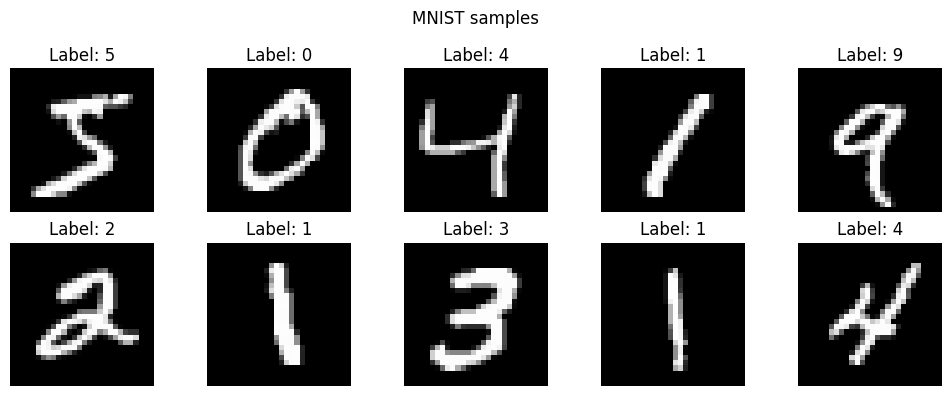

In [8]:
# Visualise a few samples so we understand what the model is being asked to learn
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    # Tensor is already normalized; shift back roughly for display
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.suptitle("MNIST samples")
plt.tight_layout()
plt.show()

### DataLoaders — feeding data to the model in batches

Training on one image at a time is slow and noisy. Instead, we use **mini-batches** (e.g. 64 images at once). The `DataLoader` handles batching, shuffling and parallel loading for us.


In [9]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Peek at a single batch
images, labels = next(iter(train_loader))
print("Batch images shape:", images.shape)   # [64, 1, 28, 28]
print("Batch labels shape:", labels.shape)   # [64]

Batch images shape: torch.Size([64, 1, 28, 28])
Batch labels shape: torch.Size([64])


## 5. The model — a Multi-Layer Perceptron (MLP)

An **MLP** is a stack of fully-connected (linear) layers separated by non-linearities.

```
input (784)  →  Linear → ReLU  →  Linear → ReLU  →  Linear → logits (10)
```

Why these pieces?
- **Linear layer**: `y = W·x + b` — learnable weight matrix and bias.
- **ReLU activation**: `max(0, x)` — adds non-linearity so the network can learn complex patterns. Without it, stacking linear layers is mathematically equivalent to a single linear layer.
- **Output layer**: 10 numbers (one per digit class). We *don't* apply softmax here — `CrossEntropyLoss` does it internally.

We define the model by subclassing `nn.Module`. Two methods are required:
- `__init__` — declare the layers.
- `forward` — describe how data flows through them.


In [10]:
class MLP(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=128, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()                 # (B,1,28,28) -> (B,784)
        self.fc1     = nn.Linear(input_dim,  hidden_dim)
        self.fc2     = nn.Linear(hidden_dim, hidden_dim)
        self.fc3     = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP().to(device)
print(model)

# How many parameters does this model have?
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {n_params:,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)
Total trainable parameters: 118,282


## 6. Loss function and optimizer

- **Loss function**: `CrossEntropyLoss` — the standard choice for multi-class classification. It expects raw logits and the integer class label.
- **Optimizer**: `Adam` — adaptive learning-rate optimizer that works well out of the box.

The learning rate (`lr`) controls how big each weight update is. Too large → unstable. Too small → very slow learning.


In [11]:
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
print("Loss     :", criterion)
print("Optimizer:", optimizer)

Loss     : CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 7. The training loop

This is the **single most important pattern** in deep learning. Memorise the five steps:

1. **Forward pass** — `outputs = model(inputs)`
2. **Compute loss** — `loss = criterion(outputs, targets)`
3. **Zero gradients** — `optimizer.zero_grad()`  *(otherwise gradients accumulate)*
4. **Backward pass** — `loss.backward()`
5. **Optimizer step** — `optimizer.step()`

We run this for many **epochs** (one epoch = one full pass over the training data).


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                                 # tells layers like Dropout/BN we are training
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        # 1. Forward pass
        outputs = model(images)
        # 2. Loss
        loss = criterion(outputs, labels)
        # 3. Zero gradients
        optimizer.zero_grad()
        # 4. Backward
        loss.backward()
        # 5. Update weights
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()                                  # disable gradient tracking for speed
def evaluate(model, loader, criterion, device):
    model.eval()                                  # tells layers we are evaluating
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)
    return running_loss / total, correct / total

In [13]:
EPOCHS = 5
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["test_loss"].append(te_loss);  history["test_acc"].append(te_acc)

    print(f"Epoch {epoch}/{EPOCHS} | "
          f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "
          f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")

Epoch 1/5 | train_loss=0.2565 train_acc=0.9234 | test_loss=0.1431 test_acc=0.9549
Epoch 2/5 | train_loss=0.1054 train_acc=0.9674 | test_loss=0.1040 test_acc=0.9661
Epoch 3/5 | train_loss=0.0740 train_acc=0.9764 | test_loss=0.0784 test_acc=0.9747
Epoch 4/5 | train_loss=0.0557 train_acc=0.9821 | test_loss=0.0923 test_acc=0.9741
Epoch 5/5 | train_loss=0.0454 train_acc=0.9843 | test_loss=0.0786 test_acc=0.9766


## 8. Visualise training progress

Plotting the loss and accuracy curves tells us whether the model is learning correctly. We hope to see:
- **Loss going down** epoch after epoch.
- **Accuracy going up**.
- Train and test curves staying close together (no big gap = no severe overfitting).


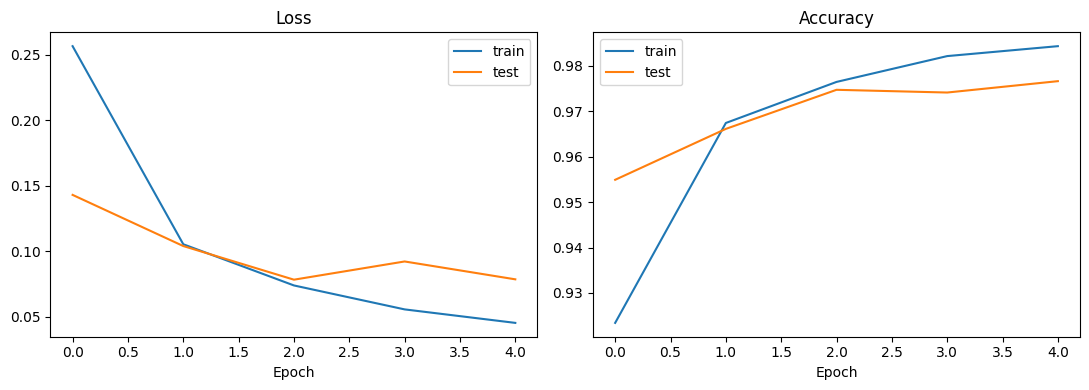

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"],  label="test")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"],  label="test")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Inspect predictions on real test images

A number is just a number — let's actually look at what the model predicts.


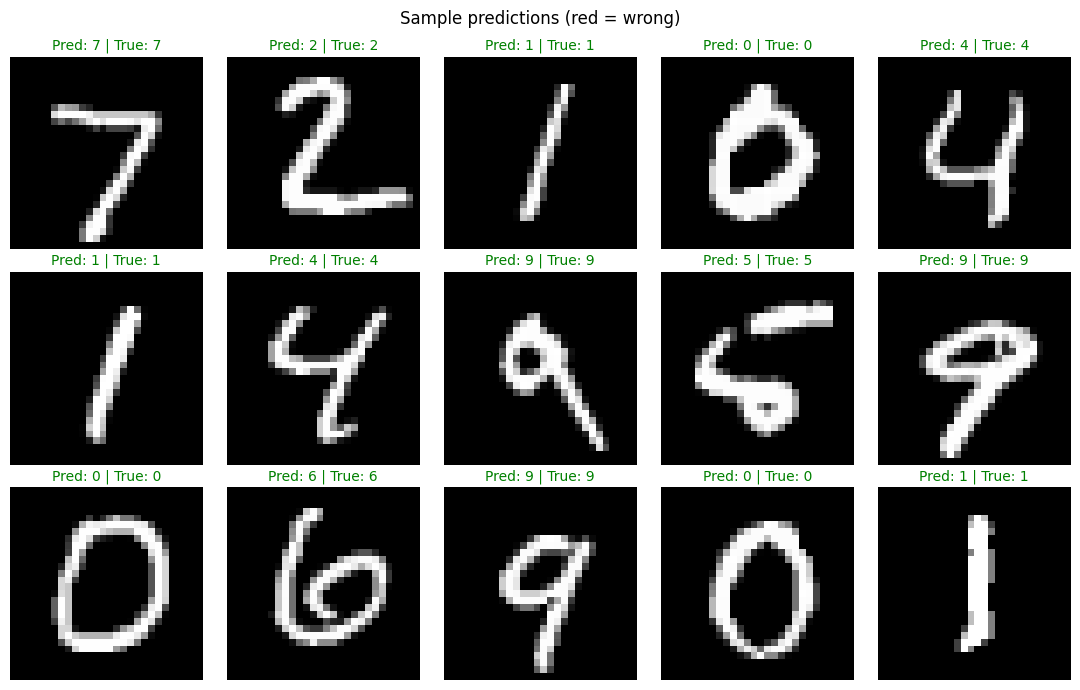

In [15]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Show a 3x5 grid
fig, axes = plt.subplots(3, 5, figsize=(11, 7))
for i, ax in enumerate(axes.flat):
    img = images[i].cpu().squeeze().numpy()
    true = labels[i].item()
    pred = preds[i].item()
    ax.imshow(img, cmap="gray")
    color = "green" if pred == true else "red"
    ax.set_title(f"Pred: {pred} | True: {true}", color=color, fontsize=10)
    ax.axis("off")
plt.suptitle("Sample predictions (red = wrong)")
plt.tight_layout()
plt.show()

## 10. Where does the model still get confused?

A **confusion matrix** shows, for each true class, how many samples were predicted as each other class. The diagonal is correct predictions; everything off-diagonal is a mistake.


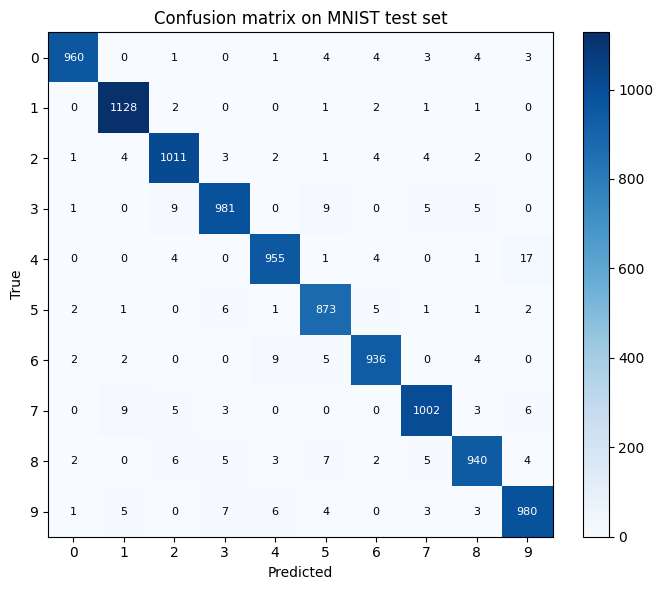

In [16]:
# Collect predictions for the entire test set
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        preds = model(images).argmax(dim=1).cpu()
        all_preds.append(preds)
        all_labels.append(labels)

all_preds  = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

# Build a 10x10 confusion matrix manually
cm = np.zeros((10, 10), dtype=int)
for t, p in zip(all_labels, all_preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Confusion matrix on MNIST test set")
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.045)
plt.tight_layout()
plt.show()

## 11. Save the trained model

In real projects you train once and reuse the model many times. We save just the **state dict** (the learned weights) — the cleanest, most portable format.


In [17]:
torch.save(model.state_dict(), "mnist_mlp.pth")
print("Model saved to mnist_mlp.pth")

# How to load it back later:
# new_model = MLP().to(device)
# new_model.load_state_dict(torch.load("mnist_mlp.pth", map_location=device))
# new_model.eval()

Model saved to mnist_mlp.pth


## 12. Recap

Today you:
- Worked with **tensors** and saw how **autograd** computes gradients automatically.
- Loaded MNIST through `torchvision` and used a `DataLoader` to feed mini-batches.
- Built an **MLP** by subclassing `nn.Module`.
- Wrote a **training loop** with the canonical 5 steps (forward → loss → zero_grad → backward → step).
- Evaluated the model with accuracy curves, sample predictions and a confusion matrix.
- **Saved** the trained model to disk.

Tomorrow we replace the MLP with a **Convolutional Neural Network (CNN)** — the right tool for images.

---

### Exercises (try at home)
1. Change `hidden_dim` from 128 → 256 → 512. Does test accuracy change?
2. Try a different optimizer (`optim.SGD(model.parameters(), lr=0.01, momentum=0.9)`).
3. Increase `EPOCHS` to 10. Does the gap between train and test grow? (That would be **overfitting** — we will fix this on Day 2.)
4. Replace MNIST with **Fashion-MNIST** (`datasets.FashionMNIST`). Same code, harder problem — what test accuracy do you get?
